# 03 – Upsell / Cross-Sell Recommendation Engine
## Business Context
ServiceTitan sells modular add-ons to existing contractor accounts:
- **Marketing Pro** – automated review requests, campaigns
- **Phones Pro** – call tracking, recording, transcription
- **Financing** – customer financing options at point of sale
- **Dispatch Pro** – advanced scheduling optimization
- **Payroll** – technician payroll management
- **Inventory** – parts/truck inventory tracking

Goal: **rank add-on products by purchase likelihood** for each account,
so the sales/CSM team contacts the right accounts about the right products.

## ML Framing
For each (account, product) pair not yet owned: predict `P(purchase within 90 days)`.
Since the catalog is small (O(10) products), we train **per-product binary classifiers**
rather than a collaborative filtering system.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Account + Purchase History ─────────────────────────────────────
N_ACCOUNTS = 3000
PRODUCTS = ['marketing_pro', 'phones_pro', 'financing', 'dispatch_pro',
            'payroll', 'inventory']

# Account features
tenure_months   = np.random.exponential(18, N_ACCOUNTS).clip(1, 72).astype(int)
seat_count      = np.random.lognormal(1.5, 0.8, N_ACCOUNTS).clip(2, 60).astype(int)
trade           = np.random.choice(['hvac','plumbing','electrical','multi'], N_ACCOUNTS,
                                   p=[0.35, 0.30, 0.20, 0.15])
jobs_per_month  = np.random.lognormal(3.5, 0.7, N_ACCOUNTS)
mau_pct         = np.random.beta(5, 2, N_ACCOUNTS).clip(0.1, 1.0)
uses_scheduling = np.random.binomial(1, 0.7, N_ACCOUNTS)
uses_invoicing  = np.random.binomial(1, 0.8, N_ACCOUNTS)
uses_marketing  = np.random.binomial(1, 0.4, N_ACCOUNTS)  # base product usage

# Current product ownership (each account starts with some products)
# Represented as a matrix: accounts × products
def simulate_ownership():
    """Simulate which products each account already owns."""
    # Ownership probabilities — more common products purchased earlier in lifecycle
    base_probs = {
        'marketing_pro': 0.30, 'phones_pro': 0.25, 'financing': 0.20,
        'dispatch_pro':  0.15, 'payroll': 0.35, 'inventory': 0.25
    }
    owned = {}
    for p, prob in base_probs.items():
        # Tenure and size increase ownership probability
        p_adj = prob + 0.01 * (tenure_months / 12) + 0.005 * np.log1p(seat_count)
        p_adj = p_adj.clip(0, 0.9)
        owned[p] = np.random.binomial(1, p_adj, N_ACCOUNTS)
    return pd.DataFrame(owned)

ownership = simulate_ownership()

# Build dataset for one product: 'marketing_pro'
# Target: will this account purchase 'marketing_pro' in the next 90 days?
# Only include accounts that DON'T already own it (they're the candidates)
def make_upsell_dataset(product):
    """Build a training dataset for a given upsell product."""
    # Eligible = doesn't already own the product
    eligible = ownership[product] == 0
    
    # Features
    df = pd.DataFrame({
        'tenure_months':   tenure_months,
        'seat_count':      seat_count,
        'trade':           trade,
        'jobs_per_month':  jobs_per_month,
        'mau_pct':         mau_pct,
        'uses_scheduling': uses_scheduling,
        'uses_invoicing':  uses_invoicing,
        'uses_marketing':  uses_marketing,
        'n_products_owned': ownership.sum(axis=1),  # total products already owned
    })
    
    # Add other-product ownership as features (market basket signal)
    for p in PRODUCTS:
        if p != product:
            df[f'owns_{p}'] = ownership[p]
    
    df = df[eligible].copy()
    
    # Generate purchase label
    # Propensity driven by usage breadth, tenure, and product-specific logic
    if product == 'marketing_pro':
        log_odds = (-2 + 0.5*df['uses_marketing'] + 0.02*df['tenure_months']
                    + 0.3*np.log1p(df['jobs_per_month']) - 1.5*(df['trade']=='plumbing'))
    elif product == 'dispatch_pro':
        log_odds = (-3 + 0.8*df['uses_scheduling'] + 0.03*df['tenure_months']
                    + 0.5*np.log1p(df['seat_count']))
    else:
        log_odds = (-2.5 + 0.02*df['tenure_months'] + 0.3*df['n_products_owned']
                    + 0.3*np.log1p(df['seat_count']))
    
    purchase_prob = 1 / (1 + np.exp(-log_odds))
    df['purchased'] = (np.random.random(len(df)) < purchase_prob).astype(int)
    
    return df

marketing_df = make_upsell_dataset('marketing_pro')
print(f"Eligible accounts for marketing_pro upsell: {len(marketing_df)}")
print(f"Purchase rate (90-day window): {marketing_df['purchased'].mean():.1%}")


Eligible accounts for marketing_pro upsell: 2046
Purchase rate (90-day window): 31.6%


In [3]:
# ─── Per-product XGBoost Classifier ──────────────────────────────────────────
def train_upsell_model(df, label_col='purchased'):
    feature_cols = [c for c in df.columns if c != label_col]
    # Encode categoricals
    df_enc = pd.get_dummies(df[feature_cols], columns=['trade'])
    X, y   = df_enc, df[label_col]
    
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               random_state=42, stratify=y)
    
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                scale_pos_weight=spw, verbosity=0, random_state=42)
    model.fit(X_tr, y_tr)
    
    # Calibrate probabilities: Platt scaling ensures P(purchase)=0.3 means 30% actually buy
    calibrated = CalibratedClassifierCV(model, method='sigmoid', cv=5)
    calibrated.fit(X_tr, y_tr)
    
    probs = calibrated.predict_proba(X_te)[:, 1]
    prauc = average_precision_score(y_te, probs)
    return calibrated, df_enc.columns.tolist(), probs, y_te, prauc

model_mktg, feat_cols, probs_mktg, y_te, prauc = train_upsell_model(marketing_df)
print(f"Marketing Pro upsell model PR-AUC: {prauc:.3f}")

# Train models for all products and compare
print("\n=== PR-AUC by Product ===")
models = {}
for prod in PRODUCTS:
    df_prod = make_upsell_dataset(prod)
    m, fcols, _, y_t, auc = train_upsell_model(df_prod)
    models[prod] = (m, fcols)
    print(f"  {prod:<20}: PR-AUC={auc:.3f}  (n={len(df_prod)}, rate={df_prod['purchased'].mean():.1%})")


Marketing Pro upsell model PR-AUC: 0.369

=== PR-AUC by Product ===


  marketing_pro       : PR-AUC=0.451  (n=2046, rate=31.7%)


  phones_pro          : PR-AUC=0.366  (n=2164, rate=23.5%)


  financing           : PR-AUC=0.302  (n=2337, rate=23.8%)


  dispatch_pro        : PR-AUC=0.399  (n=2490, rate=28.7%)


  payroll             : PR-AUC=0.274  (n=1865, rate=22.9%)


  inventory           : PR-AUC=0.287  (n=2176, rate=22.2%)


## Calibration Check
A well-calibrated model means: accounts scored at 0.3 purchase probability
should actually purchase ~30% of the time. This is critical for business decisions
— CSMs need to trust that the scores represent real probabilities.


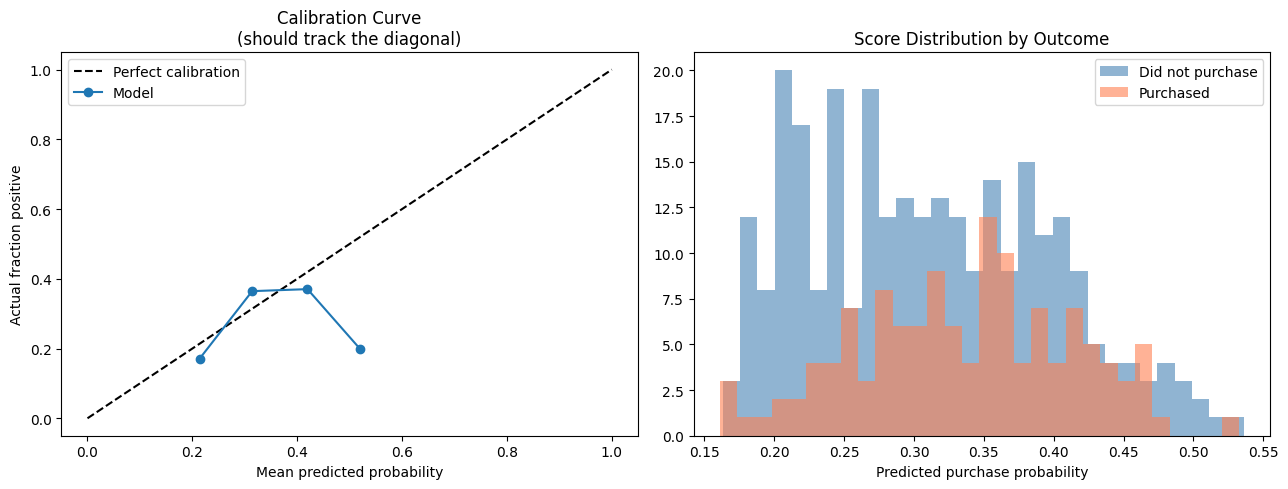

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_te, probs_mktg, n_bins=8)
axes[0].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0].plot(mean_predicted_value, fraction_of_positives, 'o-', label='Model')
axes[0].set_title('Calibration Curve\n(should track the diagonal)')
axes[0].set_xlabel('Mean predicted probability'); axes[0].set_ylabel('Actual fraction positive')
axes[0].legend()

# Score distribution
axes[1].hist(probs_mktg[y_te==0], bins=30, alpha=0.6, label='Did not purchase', color='steelblue')
axes[1].hist(probs_mktg[y_te==1], bins=30, alpha=0.6, label='Purchased', color='coral')
axes[1].set_title('Score Distribution by Outcome')
axes[1].set_xlabel('Predicted purchase probability'); axes[1].legend()

plt.tight_layout()
plt.savefig('upsell_eval.png', dpi=100, bbox_inches='tight')
plt.show()


In [5]:
# ─── Ranking & Utility Score ─────────────────────────────────────────────────
# Don't just rank by raw propensity — weight by expected revenue impact
# Utility = propensity × expected_ACV × (1 - already_owns)
acv = {  # approximate annual contract value per add-on
    'marketing_pro': 3000, 'phones_pro': 2000, 'financing': 1500,
    'dispatch_pro': 4000,  'payroll': 2500,    'inventory': 2000
}

# Score a sample of accounts across all products
n_sample = 200
sample_idx = np.random.choice(N_ACCOUNTS, n_sample, replace=False)

results = []
for prod in PRODUCTS:
    model, fcols = models[prod]
    df_prod = make_upsell_dataset(prod).reset_index(drop=True)
    if len(df_prod) == 0:
        continue
    df_enc = pd.get_dummies(df_prod[[c for c in df_prod.columns if c != 'purchased']], columns=['trade'])
    # Align columns to model's expected features
    for c in fcols:
        if c not in df_enc.columns:
            df_enc[c] = 0
    df_enc = df_enc[fcols]
    
    probs = model.predict_proba(df_enc.iloc[:min(n_sample, len(df_enc))])[:, 1]
    for i, p in enumerate(probs):
        results.append({
            'account_id': i,
            'product': prod,
            'propensity': p,
            'expected_value': p * acv[prod]
        })

recs_df = pd.DataFrame(results)

# Top recommendations per account (top-1 by expected value)
top_recs = (recs_df.sort_values('expected_value', ascending=False)
                   .groupby('account_id').first()
                   .reset_index()
                   .sort_values('expected_value', ascending=False)
                   .head(10))

print("=== Top 10 Upsell Recommendations (by expected value) ===")
print(top_recs[['account_id','product','propensity','expected_value']].to_string(index=False))

print("\n=== Product Recommendation Frequency ===")
print(recs_df.loc[recs_df.groupby('account_id')['expected_value'].idxmax(), 'product'].value_counts())


=== Top 10 Upsell Recommendations (by expected value) ===
 account_id      product  propensity  expected_value
         97 dispatch_pro    0.502918     2011.672108
          1 dispatch_pro    0.497007     1988.027985
         28 dispatch_pro    0.496815     1987.258201
        110 dispatch_pro    0.473889     1895.556807
         10 dispatch_pro    0.470885     1883.541142
        162 dispatch_pro    0.470470     1881.880319
        190 dispatch_pro    0.457711     1830.842817
        148 dispatch_pro    0.455428     1821.713273
         72 dispatch_pro    0.453210     1812.841655
         56 dispatch_pro    0.449286     1797.143620

=== Product Recommendation Frequency ===
product
dispatch_pro     131
marketing_pro     66
payroll            3
Name: count, dtype: int64


## Key Takeaways for Interview

1. **Per-product classifiers > collaborative filtering** at B2B scale (O(thousands) of accounts, O(10) products)
2. **Calibrate probabilities** — raw XGBoost scores are not probabilities; use Platt scaling
3. **Utility score = propensity × ACV** — don't just rank by probability; an 80% chance at a $500 product loses to a 40% chance at a $4,000 product
4. **Selection bias**: training data reflects CSM outreach effort, not pure account readiness — add "was_contacted" as a feature to partial this out
5. **SHAP for explanations**: CSMs need to understand *why* an account is recommended ("uses scheduling heavily but doesn't have Dispatch Pro")
